# 04. Fourier 級数と変換 — 関数を波に分解する

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Visualization |
| Applied | 5. 周波数 〜 6. 熱方程式との接続 |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

**Fourier の考え**: どんな関数も、**いろいろな振動数の正弦波(サイン・コサイン)の重ね合わせ** で表せる。

$$
f(x) = \sum_{k} \big(a_k \cos kx + b_k \sin kx\big)
$$

これが PDE で決定的に効きます。なぜなら正弦波は熱方程式・波動方程式の **固有関数** で、
個々の波の時間発展が簡単に書けるからです(05 章へ)。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import grids, solvers, plotting, datasets

## 4. Visualization — 矩形波を波で組み立てる

不連続な **矩形波** でさえ、サイン波の和で近似できます。項数を増やすほど近似が改善しますが、
跳びの近くでは行き過ぎ(**Gibbs 現象**)が残ります。

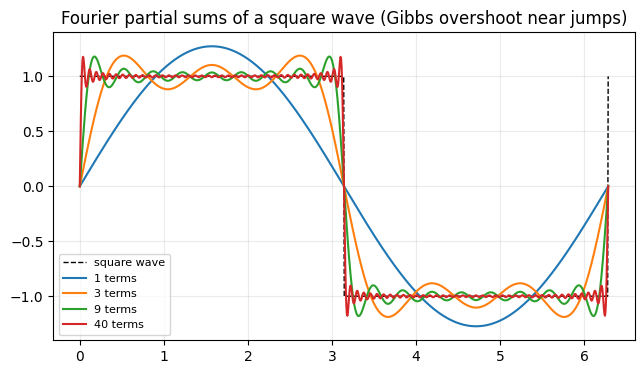

In [3]:
import numpy as np

# Build a square wave from sine terms; more terms -> better fit (but Gibbs overshoot at jumps).
x = np.linspace(0, 2 * np.pi, 1000)
target = np.where((x % (2 * np.pi)) < np.pi, 1.0, -1.0)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(x, target, "k--", lw=1, label="square wave")
for n in (1, 3, 9, 40):
    ax.plot(x, solvers.square_wave_partial_sum(x, n, L=np.pi), lw=1.5, label=f"{n} terms")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.set_title("Fourier partial sums of a square wave (Gibbs overshoot near jumps)")
plt.show()

### インタラクティブ: 項数を動かす(静的 HTML でも動く)

スライダーで項数を増やすと近似が改善し、跳びの近くに **Gibbs の行き過ぎ** が残る様子が見えます
(Plotly なのでエクスポート HTML でも動作)。

In [4]:
import plotly.io as pio
from pde_book import interactive

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = interactive.plotly_fourier_square()
fig.show()

**アニメーション**(Play で再生):項を 1 つずつ足していくと、部分和が矩形波へ収束していく様子
(各フレーム = 項数 1 つ増加)。

In [5]:
# Fourier partial sum building up term by term (reuses the field-evolution animator).
xb = np.linspace(0, 2 * np.pi, 800)
Ub = np.array([solvers.square_wave_partial_sum(xb, n, np.pi) for n in range(1, 31)])
interactive.plotly_field_evolution(xb, Ub, step=1, duration=250, ylim=(-1.4, 1.4),
                                   title="Fourier partial sum building up (term by term)").show()

## 5. 周波数 — 低周波と高周波 (Applied)

各サイン波の「振動数(周波数)」が、信号のどの成分を担うかを表します。
複数の周波数を混ぜた信号を作り、**FFT(高速 Fourier 変換)** で周波数成分を取り出します。
スパイクが立つ位置が、混ぜた周波数です。

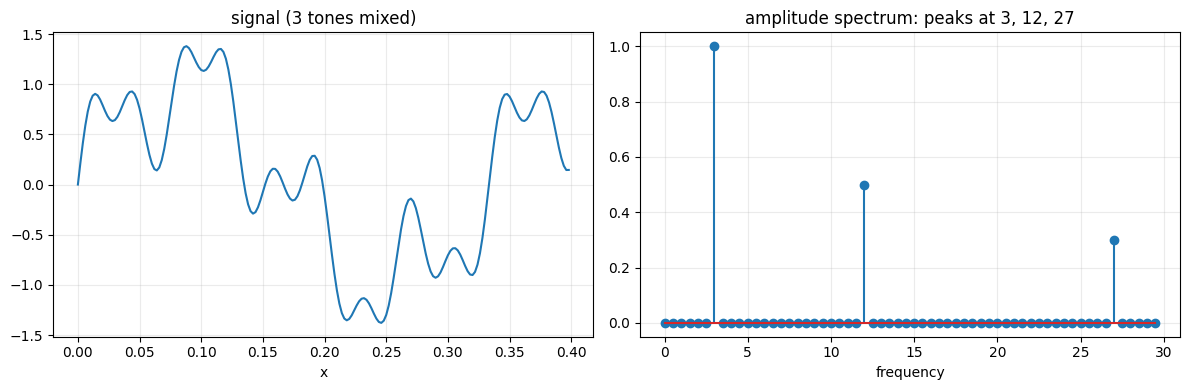

In [6]:
import numpy as np

# A signal = sum of a few pure tones; the FFT recovers their frequencies.
fs = 500                                  # samples per unit
x = np.arange(0, 2, 1 / fs)
freqs = [3, 12, 27]
amps = [1.0, 0.5, 0.3]
signal = sum(a * np.sin(2 * np.pi * f * x) for f, a in zip(freqs, amps))

spectrum = np.abs(np.fft.rfft(signal)) / (len(x) / 2)
freq_axis = np.fft.rfftfreq(len(x), 1 / fs)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(x[:200], signal[:200], color="#1f77b4")
a1.set_title("signal (3 tones mixed)")
a1.set_xlabel("x")
a1.grid(alpha=0.25)
a2.stem(freq_axis[:60], spectrum[:60])
a2.set_title("amplitude spectrum: peaks at 3, 12, 27")
a2.set_xlabel("frequency")
a2.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 6. 熱方程式との接続 — 高周波は速く消える

熱方程式は、各 Fourier モード $\sin(kx)$ を **$e^{-\alpha k^2 t}$ で減衰** させます。
$k$(周波数)が大きいほど減衰が速い——だから熱方程式は **高周波(細かいでこぼこ)から先に消す** = 平滑化。
低周波 + 高周波を混ぜた初期条件を熱方程式で時間発展させ、高周波が先に消えることを見ます。

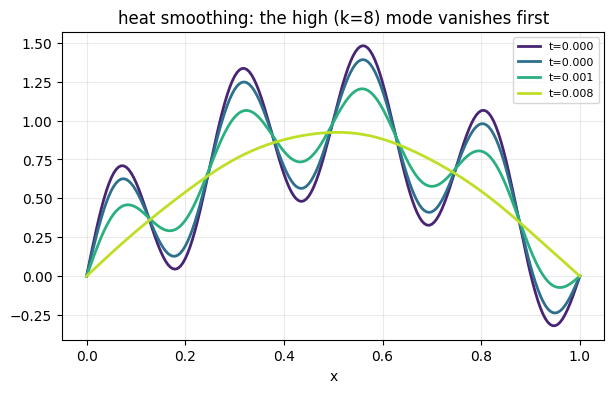

In [7]:
import numpy as np

# Heat kills high modes first: mode k decays like e^{-alpha k^2 t}.
g = grids.Grid1D(0.0, 1.0, 201)
x, dx = g.x, g.dx
alpha = 1.0
u0 = datasets.sine_combo(x, modes=(1, 8), amps=(1.0, 0.5), L=1.0)  # low + high frequency
dt = 0.4 * dx**2 / alpha
U = solvers.solve_heat_explicit(u0, alpha, dx, dt, steps=800)
ax = plotting.plot_field_snapshots(x, U, [0, 30, 120, 800], dt=dt,
                                   title="heat smoothing: the high (k=8) mode vanishes first")
plt.show()

## Exercises

1. 三角波の Fourier 級数を求め、矩形波より速く収束する(Gibbs が穏やか)ことを観察せよ。
2. FFT で、サンプリング周波数の半分(Nyquist)を超える周波数が折り返す(エイリアシング)様子を作れ。
3. 熱方程式で、モード $n=1$ と $n=4$($\sin(n\pi x)$, 固有値 $(n\pi)^2$)の振幅比が
   時間とともに $e^{-\alpha(1-16)\pi^2 t}=e^{15\alpha\pi^2 t}$ で変化することを数値で確かめよ。

## Advanced Notes

- **Fourier 変換**: 非周期関数には級数の代わりに変換 $\hat{f}(\omega)=\int f(x)e^{-i\omega x}dx$ を使う。微分が $i\omega$ 倍に化けるので PDE が代数方程式になる。
- **Parseval の定理**: 信号のエネルギーは時間領域でも周波数領域でも等しい($\int|f|^2 = \frac{1}{2\pi}\int|\hat f|^2$)。
- **Gibbs 現象**: 不連続点での行き過ぎ(約 9%)は項数を増やしても消えない(幅は狭まる)。Fejér 平均などで緩和できる。
- **スペクトル法**: 周期境界の PDE は FFT で空間微分を高精度に評価でき、有限差分より速く正確なことがある。